In [1]:
import tensorflow as tf

In [2]:
#Load Dataset
fmnist = tf.keras.datasets.fashion_mnist

In [3]:
fmnist

<module 'keras.datasets.fashion_mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/fashion_mnist/__init__.py'>

In [4]:
# Load the training and test split of the Fashion MNIST dataset
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
training_images.shape,test_images.shape

((60000, 28, 28), (10000, 28, 28))

In [6]:
training_labels,test_labels

(array([9, 0, 0, ..., 3, 0, 5], dtype=uint8),
 array([9, 2, 1, ..., 8, 1, 5], dtype=uint8))

LABEL: 0

IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   0   0   0   0  22 118  24   0   0   0   0   0  48  88   5   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  12 100 212 205 185 179 173 186 193 221 142  85   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  85  76 199 225 248 255 238 226 157  68  80   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  91  69  91 201 218 225 209 158  61  93  72   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  79  89  61  59  87 108  75  56  76  97  73   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  75  89  80  80  67  63  73  83  80  96  72   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  77  88  77  80  83  83  83  83  81  95  76   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  89  96  80  83  81  84  85  85  85  97  84   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  93  97  81 

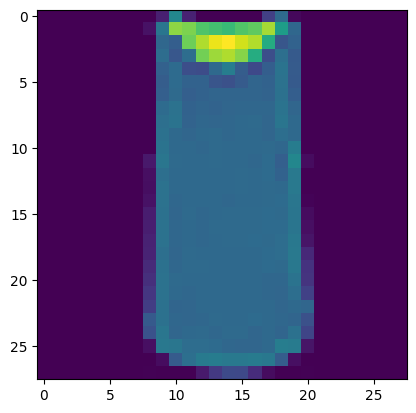

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
index = 2

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'LABEL: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
plt.imshow(training_images[index])
plt.show()

In [8]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
# Build the classification model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(),           # Flattens input (e.g. 28x28 to 784)
    tf.keras.layers.Dense(128, activation='relu'),  # Hidden layer
    tf.keras.layers.Dense(10, activation='softmax') # Output layer for 10 classes
])

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Define the callback function
early_stopping = EarlyStopping(patience=5)
model.fit(training_images, training_labels,verbose=1,validation_split=0.2, epochs=100,callbacks=[early_stopping])

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8215 - loss: 0.5124 - val_accuracy: 0.8512 - val_loss: 0.4217
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8597 - loss: 0.3877 - val_accuracy: 0.8648 - val_loss: 0.3783
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8748 - loss: 0.3411 - val_accuracy: 0.8726 - val_loss: 0.3531
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8832 - loss: 0.3167 - val_accuracy: 0.8768 - val_loss: 0.3405
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8894 - loss: 0.2986 - val_accuracy: 0.8706 - val_loss: 0.3635
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8952 - loss: 0.2813 - val_accuracy: 0.8773 - val_loss: 0.3426
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8985 - loss: 0.2707 - val_accuracy: 0.8798 - val_loss: 0.3326
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9038 - loss: 0

In [12]:
# Evaluate the model on unseen data
loss,accuracy= model.evaluate(test_images, test_labels)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8834 - loss: 0.3765
Loss: 0.3764813244342804
Accuracy: 0.883400022983551


In [13]:
classifications = model.predict(test_images)
print('Probability of Each Class')
print(classifications[2])
print()
print('Rounded Classification')
rounded_classification = np.round(classifications,2)
print(rounded_classification[2])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Probability of Each Class
[3.9331234e-12 9.9999994e-01 7.0320675e-16 1.2314601e-11 2.0140925e-11 1.2932367e-16 1.2535837e-13 7.6642630e-21 5.3165664e-19 6.3018541e-21]

Rounded Classification
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [14]:
print(test_labels[2])

1
